# Feature Engineering Check: dev_profile_final_v4

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

DB_PATH = 'developer_project.duckdb'
con = duckdb.connect(DB_PATH)

TABLE = 'dev_profile_final_v4'
print('Connected to:', DB_PATH)

Connected to: developer_project.duckdb


## 1. Basic Dataset Overview

In [3]:
overview = con.execute(f"""
SELECT
    COUNT(*)                                 AS total_rows,
    COUNT(DISTINCT developer_id)             AS unique_developers,
    COUNT(*) - COUNT(DISTINCT developer_id)  AS duplicate_rows
FROM {TABLE}
""").fetchdf()
display(overview)
if overview.loc[0, 'duplicate_rows'] > 0:
    print('WARNING: duplicate developer_id rows detected!')
else:
    print('OK: one row per developer')

,total_rows,unique_developers,duplicate_rows
0,9381508,9381508,0


OK: one row per developer


In [4]:
# Column names and types straight from DuckDB
schema = con.execute(f"DESCRIBE {TABLE}").fetchdf()
print(f'Total columns: {len(schema)}')
display(schema)

Total columns: 145


,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,persona,VARCHAR,YES,None,None,None
2,persona_confidence,DOUBLE,YES,None,None,None
3,persona_confidence_tier,VARCHAR,YES,None,None,None
4,persona_entropy,DOUBLE,YES,None,None,None
...,...,...,...,...,...,...
140,organization_english_name,VARCHAR,YES,None,None,None
141,normalized_account_name,VARCHAR,YES,None,None,None
142,wwfo_category,VARCHAR,YES,None,None,None
143,wwfo_target_list,VARCHAR,YES,None,None,None


## 2. Missing Value Audit (all columns)

In [5]:
cols = con.execute(f"DESCRIBE {TABLE}").fetchdf()['column_name'].tolist()
total_rows = con.execute(f"SELECT COUNT(*) FROM {TABLE}").fetchone()[0]

# Build one big SELECT with a null count per column
null_exprs = ',\n    '.join(
    f"SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) AS {c}" for c in cols
)
null_counts = con.execute(f"SELECT {null_exprs} FROM {TABLE}").fetchdf()

missing = (
    null_counts.T
    .reset_index()
    .rename(columns={'index': 'column', 0: 'null_count'})
)
missing['null_pct'] = (missing['null_count'] / total_rows * 100).round(2)
missing = missing.sort_values('null_count', ascending=False)

with_nulls = missing[missing['null_count'] > 0]
print(f'Columns with nulls: {len(with_nulls)} / {len(missing)}')
display(with_nulls)
print(f'Columns with zero nulls: {(missing["null_count"] == 0).sum()}')

Columns with nulls: 31 / 145


,column,null_count,null_pct
68,build_velocity_0_30_vs_30_90,9290121.0000,99.0300
51,build_share_0_30d,8963459.0000,95.5400
52,high_effort_share_0_30d,8963459.0000,95.5400
59,confidence_weighted_effort_per_activity_0_30d,8963459.0000,95.5400
65,days_since_last_activity_0_30d,8963459.0000,95.5400
50,activity_per_active_day_0_30d,8963459.0000,95.5400
62,score_effort_misalignment_share_0_30d,8963459.0000,95.5400
67,activity_velocity_0_30_vs_30_90,8956236.0000,95.4700
22,days_since_last_meaningful_week,5284222.0000,56.3300
21,last_meaningful_week_start,5284222.0000,56.3300


Columns with zero nulls: 114


## 3. Persona Features

In [6]:
print('=== Persona distribution ===')
display(con.execute(f"""
SELECT persona, COUNT(*) AS developers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM {TABLE}
GROUP BY 1 ORDER BY 2 DESC
""").fetchdf())

print('\n=== Persona confidence tier ===')
display(con.execute(f"""
SELECT persona_confidence_tier, COUNT(*) AS developers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM {TABLE}
GROUP BY 1 ORDER BY 2 DESC
""").fetchdf())

=== Persona distribution ===


,persona,developers,pct
0,CUDA,3519981,37.5200
1,GenAI,2314671,24.6700
2,Unknown,1869569,19.9300
3,Robotics,590804,6.3000
4,Simulation,570051,6.0800
5,Learning_Community,516432,5.5000



=== Persona confidence tier ===


,persona_confidence_tier,developers,pct
0,High,4405858,46.9600
1,Medium,2393443,25.5100
2,Unknown,1869569,19.9300
3,Low,712638,7.6000


In [7]:
print('Range checks — persona numeric cols (all should be 0–1):')
display(con.execute(f"""
SELECT
    MIN(persona_confidence)          AS pc_min,   MAX(persona_confidence)          AS pc_max,
    MIN(persona_entropy)             AS pe_min,   MAX(persona_entropy)             AS pe_max,
    MIN(cuda_share)                  AS cu_min,   MAX(cuda_share)                  AS cu_max,
    MIN(genai_share)                 AS ge_min,   MAX(genai_share)                 AS ge_max,
    MIN(robotics_share)              AS ro_min,   MAX(robotics_share)              AS ro_max,
    MIN(simulation_share)            AS si_min,   MAX(simulation_share)            AS si_max,
    MIN(learning_community_share)    AS lc_min,   MAX(learning_community_share)    AS lc_max
FROM {TABLE}
""").fetchdf())

print('\nOut-of-range violations (value < 0 or > 1):')
display(con.execute(f"""
SELECT
    SUM(CASE WHEN persona_confidence < 0 OR persona_confidence > 1 THEN 1 ELSE 0 END) AS persona_confidence,
    SUM(CASE WHEN persona_entropy    < 0 OR persona_entropy    > 1 THEN 1 ELSE 0 END) AS persona_entropy,
    SUM(CASE WHEN cuda_share         < 0 OR cuda_share         > 1 THEN 1 ELSE 0 END) AS cuda_share,
    SUM(CASE WHEN genai_share        < 0 OR genai_share        > 1 THEN 1 ELSE 0 END) AS genai_share,
    SUM(CASE WHEN robotics_share     < 0 OR robotics_share     > 1 THEN 1 ELSE 0 END) AS robotics_share,
    SUM(CASE WHEN simulation_share   < 0 OR simulation_share   > 1 THEN 1 ELSE 0 END) AS simulation_share,
    SUM(CASE WHEN learning_community_share < 0 OR learning_community_share > 1 THEN 1 ELSE 0 END) AS learning_community_share
FROM {TABLE}
""").fetchdf())

print('\nmixed_persona_flag values:')
display(con.execute(f"SELECT mixed_persona_flag, COUNT(*) AS n FROM {TABLE} GROUP BY 1").fetchdf())

Range checks — persona numeric cols (all should be 0–1):


,pc_min,pc_max,pe_min,pe_max,cu_min,cu_max,ge_min,ge_max,ro_min,ro_max,si_min,si_max,lc_min,lc_max
0,0.0000,1.0000,-0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000



Out-of-range violations (value < 0 or > 1):


,persona_confidence,persona_entropy,cuda_share,genai_share,robotics_share,simulation_share,learning_community_share
0,0.0000,776.0000,0.0000,0.0000,0.0000,0.0000,0.0000



mixed_persona_flag values:


,mixed_persona_flag,n
0,0,7083718
1,1,2297790


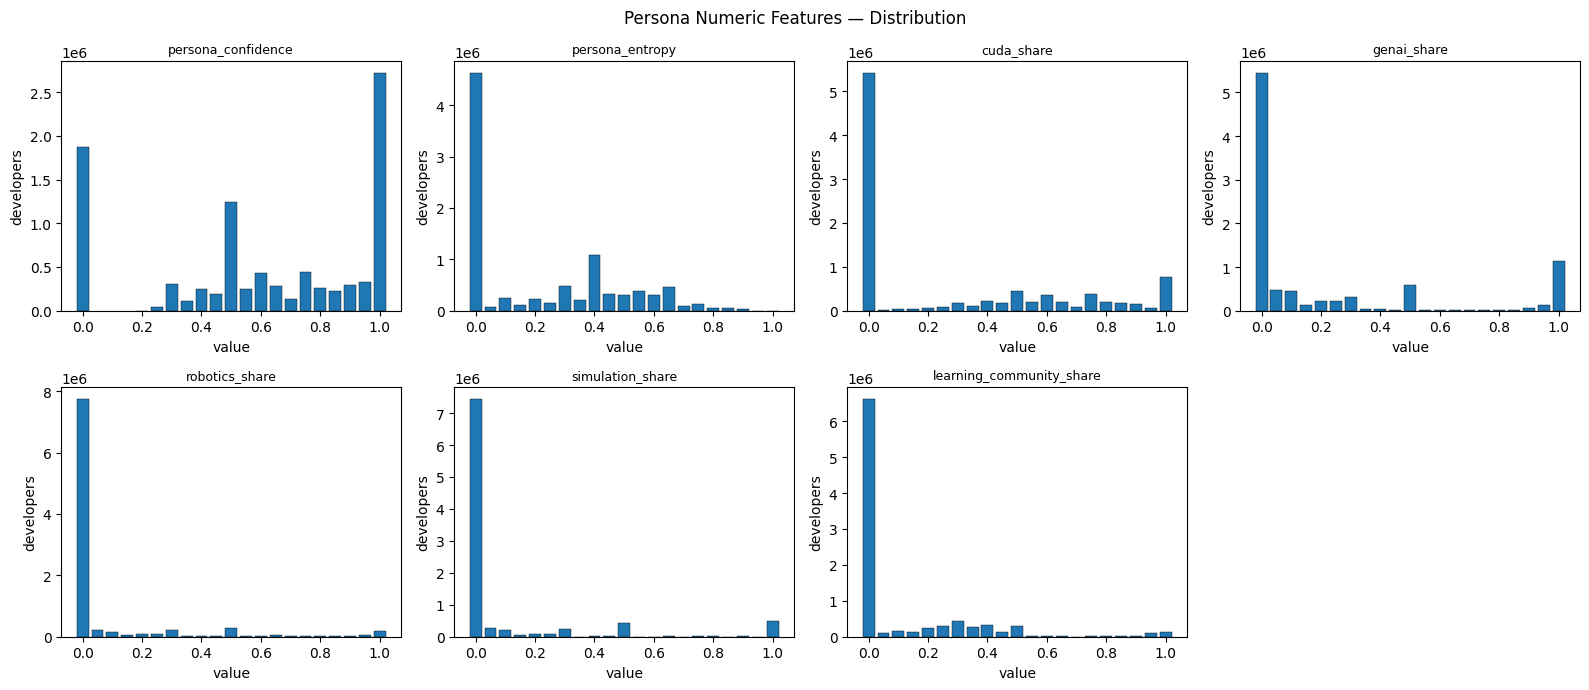

In [8]:
# Histograms via bucketed SQL
share_cols = ['persona_confidence', 'persona_entropy', 'cuda_share',
              'genai_share', 'robotics_share', 'simulation_share', 'learning_community_share']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(share_cols):
    bkt = con.execute(f"""
        SELECT FLOOR({col} * 20) / 20 AS bucket, COUNT(*) AS n
        FROM {TABLE} WHERE {col} IS NOT NULL
        GROUP BY 1 ORDER BY 1
    """).fetchdf()
    axes[i].bar(bkt['bucket'], bkt['n'], width=0.04, edgecolor='k', linewidth=0.3)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('value')
    axes[i].set_ylabel('developers')
axes[-1].set_visible(False)
plt.suptitle('Persona Numeric Features — Distribution', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Developer Effort Features

In [9]:
print('=== Effort level distribution ===')
display(con.execute(f"""
SELECT developer_effort_level, developer_effort_rank,
    COUNT(*) AS developers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct,
    ROUND(AVG(developer_effort_score), 4) AS avg_effort_score
FROM {TABLE}
GROUP BY 1, 2 ORDER BY 2 DESC
""").fetchdf())

print('\nEffort score stats:')
display(con.execute(f"""
SELECT
    ROUND(MIN(developer_effort_score), 4)    AS min,
    ROUND(MAX(developer_effort_score), 4)    AS max,
    ROUND(AVG(developer_effort_score), 4)    AS mean,
    ROUND(MEDIAN(developer_effort_score), 4) AS median,
    SUM(CASE WHEN developer_effort_score < 0 THEN 1 ELSE 0 END) AS negative_violations
FROM {TABLE}
""").fetchdf())

=== Effort level distribution ===


,developer_effort_level,developer_effort_rank,developers,pct,avg_effort_score
0,very high effort,4,766035,8.1700,1.4615
1,high effort,3,1151291,12.2700,0.7163
2,medium effort,2,2152014,22.9400,0.4676
3,low effort,1,3590938,38.2800,0.2941
4,no activity,0,1721230,18.3500,0.0000



Effort score stats:


,min,max,mean,median,negative_violations
0,0.0000,5.3391,0.4270,0.3630,0.0000


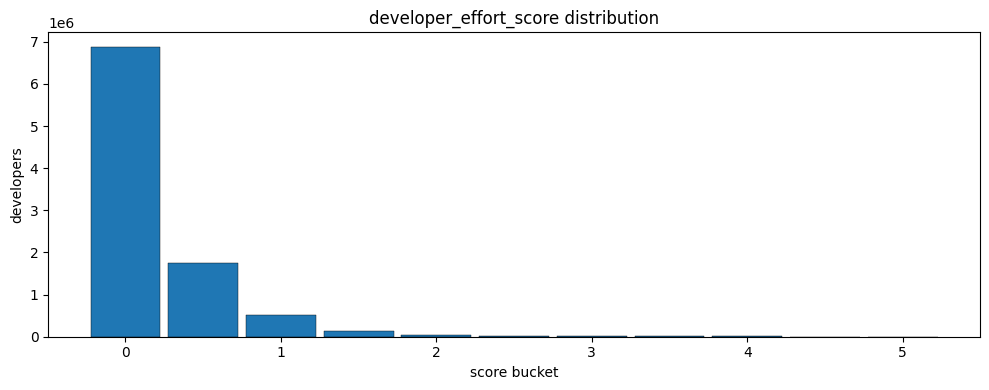

In [10]:
bkt = con.execute(f"""
    SELECT
        FLOOR(developer_effort_score / 0.5) * 0.5 AS bucket,
        COUNT(*) AS n
    FROM {TABLE}
    WHERE developer_effort_score IS NOT NULL
    GROUP BY 1 ORDER BY 1
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(bkt['bucket'], bkt['n'], width=0.45, edgecolor='k', linewidth=0.3)
ax.set_title('developer_effort_score distribution')
ax.set_xlabel('score bucket')
ax.set_ylabel('developers')
plt.tight_layout()
plt.show()

## 5. Journey Stage & Dormancy Features

In [11]:
for col in ['behavior_journey_stage_30d', 'current_journey_state_30d',
            'dormancy_status', 'final_lifecycle_status']:
    print(f'=== {col} ===')
    display(con.execute(f"""
        SELECT {col}, COUNT(*) AS developers,
            ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
        FROM {TABLE} GROUP BY 1 ORDER BY 2 DESC
    """).fetchdf())

=== behavior_journey_stage_30d ===


,behavior_journey_stage_30d,developers,pct
0,Historically_Active,6963992,74.2300
1,Unactivated,1721230,18.3500
2,Builder,319991,3.4100
3,Evaluator,289432,3.0900
4,Learner,85487,0.9100
5,Explorer,1376,0.0100


=== current_journey_state_30d ===


,current_journey_state_30d,developers,pct
0,Dormant_Historically_Active,5132624,54.7100
1,Unactivated,1721230,18.3500
2,At_Risk_Historically_Active,1499923,15.9900
3,Cooling_Historically_Active,331445,3.5300
4,Evaluator,280897,2.9900
5,Dormant_Builder,168052,1.7900
6,Learner,85487,0.9100
7,At_Risk_Builder,77223,0.8200
8,Builder,50289,0.5400
9,Cooling_Builder,24427,0.2600


=== dormancy_status ===


,dormancy_status,developers,pct
0,Dormant,5304852,56.5500
1,Unactivated,1721230,18.3500
2,At_Risk,1580877,16.8500
3,Active,418049,4.4600
4,Cooling,356500,3.8000


=== final_lifecycle_status ===


,final_lifecycle_status,developers,pct
0,Tourist,4976445,53.0500
1,Unactivated,1721230,18.3500
2,Dormant_Build,1015390,10.8200
3,Dormant_Learn,360345,3.8400
4,Dormant_Evaluate,233676,2.4900
5,AtRisk_Build,212335,2.2600
6,Active_Build,198074,2.1100
7,Active_Discover,141923,1.5100
8,AtRisk_Learn,115334,1.2300
9,FreeEmail,109622,1.1700


In [12]:
print('Binary flag validity (should only be 0 or 1):')
display(con.execute(f"""
SELECT
    SUM(CASE WHEN is_activated        NOT IN (0,1) THEN 1 ELSE 0 END) AS is_activated_violations,
    SUM(CASE WHEN dormant_flag        NOT IN (0,1) THEN 1 ELSE 0 END) AS dormant_flag_violations,
    SUM(CASE WHEN at_risk_flag        NOT IN (0,1) THEN 1 ELSE 0 END) AS at_risk_flag_violations,
    SUM(CASE WHEN cooling_flag        NOT IN (0,1) THEN 1 ELSE 0 END) AS cooling_flag_violations,
    SUM(CASE WHEN missing_contact_metadata_flag NOT IN (0,1) THEN 1 ELSE 0 END) AS contact_flag_violations
FROM {TABLE}
""").fetchdf())

print('\nCross-tab: dormancy_status x behavior_journey_stage_30d (top 20):')
display(con.execute(f"""
    SELECT dormancy_status, behavior_journey_stage_30d, COUNT(*) AS n
    FROM {TABLE}
    GROUP BY 1, 2 ORDER BY 3 DESC
    LIMIT 20
""").fetchdf())

Binary flag validity (should only be 0 or 1):


,is_activated_violations,dormant_flag_violations,at_risk_flag_violations,cooling_flag_violations,contact_flag_violations
0,0.0000,0.0000,0.0000,0.0000,0.0000



Cross-tab: dormancy_status x behavior_journey_stage_30d (top 20):


,dormancy_status,behavior_journey_stage_30d,n
0,Dormant,Historically_Active,5132624
1,Unactivated,Unactivated,1721230
2,At_Risk,Historically_Active,1499923
3,Cooling,Historically_Active,331445
4,Active,Evaluator,280897
5,Dormant,Builder,168052
6,Active,Learner,85487
7,At_Risk,Builder,77223
8,Active,Builder,50289
9,Cooling,Builder,24427


## 6. Recency Window Features (0–30d, 30–90d, 90–180d)

In [13]:
# Summary stats for activity/build/high_effort counts across windows
display(con.execute(f"""
SELECT
    ROUND(AVG(activity_count_0_30d), 2)    AS avg_act_0_30,
    ROUND(AVG(activity_count_30_90d), 2)   AS avg_act_30_90,
    ROUND(AVG(activity_count_90_180d), 2)  AS avg_act_90_180,
    ROUND(AVG(build_count_0_30d), 2)       AS avg_build_0_30,
    ROUND(AVG(build_count_30_90d), 2)      AS avg_build_30_90,
    ROUND(AVG(high_effort_count_0_30d), 2) AS avg_heff_0_30,
    ROUND(AVG(high_effort_count_30_90d), 2) AS avg_heff_30_90,
    MIN(activity_count_0_30d) AS min_act_0_30,
    MAX(activity_count_0_30d) AS max_act_0_30,
    SUM(CASE WHEN activity_count_0_30d < 0 THEN 1 ELSE 0 END) AS neg_act_0_30,
    SUM(CASE WHEN build_count_0_30d < 0 THEN 1 ELSE 0 END)    AS neg_build_0_30,
    SUM(CASE WHEN high_effort_count_0_30d < 0 THEN 1 ELSE 0 END) AS neg_heff_0_30
FROM {TABLE}
""").fetchdf())

,avg_act_0_30,avg_act_30_90,avg_act_90_180,avg_build_0_30,avg_build_30_90,avg_heff_0_30,avg_heff_30_90,min_act_0_30,max_act_0_30,neg_act_0_30,neg_build_0_30,neg_heff_0_30
0,0.3400,0.3800,0.4000,0.0600,0.1200,0.0600,0.0800,0,144228,0.0000,0.0000,0.0000


In [14]:
print('has_activity flag vs activity_count consistency:')
display(con.execute(f"""
SELECT
    SUM(CASE WHEN activity_count_0_30d   > 0 AND has_activity_0_30d   = 0 THEN 1 ELSE 0 END) AS mismatch_0_30d,
    SUM(CASE WHEN activity_count_30_90d  > 0 AND has_activity_30_90d  = 0 THEN 1 ELSE 0 END) AS mismatch_30_90d,
    SUM(CASE WHEN activity_count_90_180d > 0 AND has_activity_90_180d = 0 THEN 1 ELSE 0 END) AS mismatch_90_180d
FROM {TABLE}
""").fetchdf())

print('\nShare columns (build_share_0_30d, high_effort_share_0_30d) range:')
display(con.execute(f"""
SELECT
    MIN(build_share_0_30d)        AS build_share_min,  MAX(build_share_0_30d)        AS build_share_max,
    MIN(high_effort_share_0_30d)  AS heff_share_min,   MAX(high_effort_share_0_30d)  AS heff_share_max,
    SUM(CASE WHEN build_share_0_30d < 0 OR build_share_0_30d > 1 THEN 1 ELSE 0 END) AS build_share_violations,
    SUM(CASE WHEN high_effort_share_0_30d < 0 OR high_effort_share_0_30d > 1 THEN 1 ELSE 0 END) AS heff_share_violations
FROM {TABLE}
""").fetchdf())

has_activity flag vs activity_count consistency:


,mismatch_0_30d,mismatch_30_90d,mismatch_90_180d
0,0.0000,0.0000,0.0000



Share columns (build_share_0_30d, high_effort_share_0_30d) range:


,build_share_min,build_share_max,heff_share_min,heff_share_max,build_share_violations,heff_share_violations
0,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000


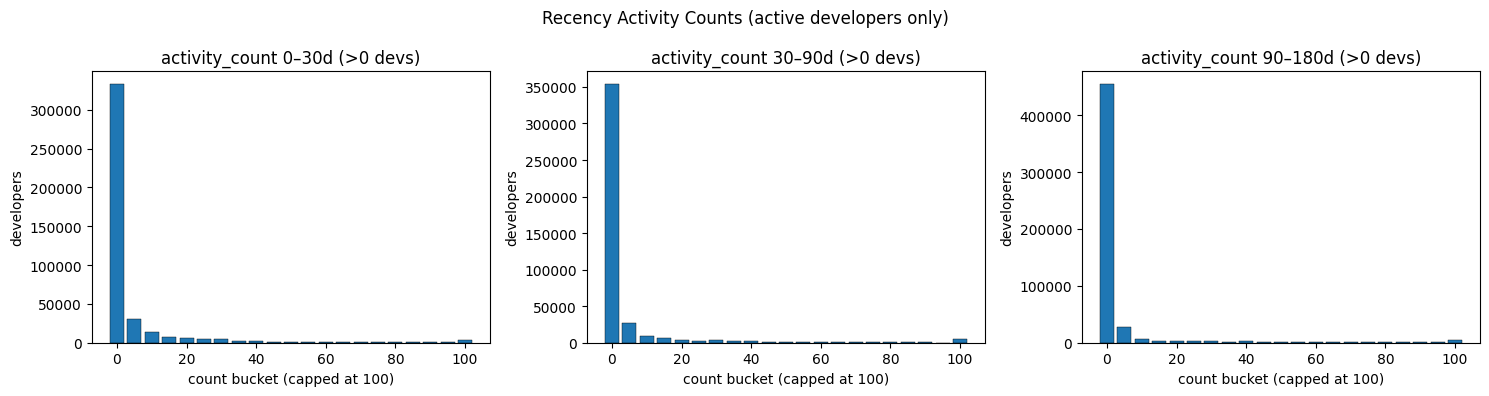

In [15]:
# Side-by-side histograms: activity count >0 across the three windows
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
windows = [('activity_count_0_30d', '0–30d'), ('activity_count_30_90d', '30–90d'), ('activity_count_90_180d', '90–180d')]
for ax, (col, label) in zip(axes, windows):
    bkt = con.execute(f"""
        SELECT LEAST(FLOOR({col} / 5) * 5, 100) AS bucket, COUNT(*) AS n
        FROM {TABLE} WHERE {col} > 0
        GROUP BY 1 ORDER BY 1
    """).fetchdf()
    ax.bar(bkt['bucket'], bkt['n'], width=4, edgecolor='k', linewidth=0.3)
    ax.set_title(f'activity_count {label} (>0 devs)')
    ax.set_xlabel('count bucket (capped at 100)')
    ax.set_ylabel('developers')
plt.suptitle('Recency Activity Counts (active developers only)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Lifetime Features

In [16]:
display(con.execute(f"""
SELECT
    MIN(lifetime_activity_count)          AS lt_act_min,
    MAX(lifetime_activity_count)          AS lt_act_max,
    ROUND(AVG(lifetime_activity_count),2) AS lt_act_avg,
    ROUND(MEDIAN(lifetime_activity_count),2) AS lt_act_med,
    MIN(lifetime_activity_score_sum)      AS lt_score_min,
    MAX(lifetime_activity_score_sum)      AS lt_score_max,
    ROUND(AVG(lifetime_activity_score_sum),2) AS lt_score_avg,
    MIN(lifetime_unique_activity_types)   AS lt_types_min,
    MAX(lifetime_unique_activity_types)   AS lt_types_max,
    MIN(lifetime_unique_modalities)       AS lt_mod_min,
    MAX(lifetime_unique_modalities)       AS lt_mod_max,
    MIN(lifetime_active_weeks)            AS lt_weeks_min,
    MAX(lifetime_active_weeks)            AS lt_weeks_max
FROM {TABLE}
""").fetchdf())

,lt_act_min,lt_act_max,lt_act_avg,lt_act_med,lt_score_min,lt_score_max,lt_score_avg,lt_types_min,lt_types_max,lt_mod_min,lt_mod_max,lt_weeks_min,lt_weeks_max
0,0,2027375,7.3900,2.0000,0.0000,10015777.0000,25.4200,0,16,0,6,0,323


In [17]:
print('Negative count checks (lifetime counts should be >= 0):')
display(con.execute(f"""
SELECT
    SUM(CASE WHEN lifetime_activity_count      < 0 THEN 1 ELSE 0 END) AS lt_activity_count_neg,
    SUM(CASE WHEN lifetime_activity_score_sum  < 0 THEN 1 ELSE 0 END) AS lt_score_sum_neg,
    SUM(CASE WHEN lifetime_build_count         < 0 THEN 1 ELSE 0 END) AS lt_build_neg,
    SUM(CASE WHEN lifetime_champion_count      < 0 THEN 1 ELSE 0 END) AS lt_champion_neg,
    SUM(CASE WHEN lifetime_high_effort_count   < 0 THEN 1 ELSE 0 END) AS lt_high_effort_neg,
    SUM(CASE WHEN lifetime_dli_training_count  < 0 THEN 1 ELSE 0 END) AS lt_dli_neg,
    SUM(CASE WHEN lifetime_webinar_count       < 0 THEN 1 ELSE 0 END) AS lt_webinar_neg,
    SUM(CASE WHEN lifetime_forum_count         < 0 THEN 1 ELSE 0 END) AS lt_forum_neg,
    SUM(CASE WHEN lifetime_api_count           < 0 THEN 1 ELSE 0 END) AS lt_api_neg,
    SUM(CASE WHEN lifetime_devzone_download_count < 0 THEN 1 ELSE 0 END) AS lt_devzone_neg,
    SUM(CASE WHEN lifetime_ngc_download_count  < 0 THEN 1 ELSE 0 END) AS lt_ngc_neg
FROM {TABLE}
""").fetchdf())

print('\nEffort rank range checks (should be 0–4):')
display(con.execute(f"""
SELECT
    MIN(lifetime_avg_effort_rank) AS avg_rank_min, MAX(lifetime_avg_effort_rank) AS avg_rank_max,
    MIN(lifetime_max_effort_rank) AS max_rank_min, MAX(lifetime_max_effort_rank) AS max_rank_max,
    SUM(CASE WHEN lifetime_avg_effort_rank < 0 OR lifetime_avg_effort_rank > 4 THEN 1 ELSE 0 END) AS avg_rank_violations,
    SUM(CASE WHEN lifetime_max_effort_rank < 0 OR lifetime_max_effort_rank > 4 THEN 1 ELSE 0 END) AS max_rank_violations
FROM {TABLE}
""").fetchdf())

Negative count checks (lifetime counts should be >= 0):


,lt_activity_count_neg,lt_score_sum_neg,lt_build_neg,lt_champion_neg,lt_high_effort_neg,lt_dli_neg,lt_webinar_neg,lt_forum_neg,lt_api_neg,lt_devzone_neg,lt_ngc_neg
0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000



Effort rank range checks (should be 0–4):


,avg_rank_min,avg_rank_max,max_rank_min,max_rank_max,avg_rank_violations,max_rank_violations
0,0.0000,4.0000,0.0000,4.0000,0.0000,0.0000


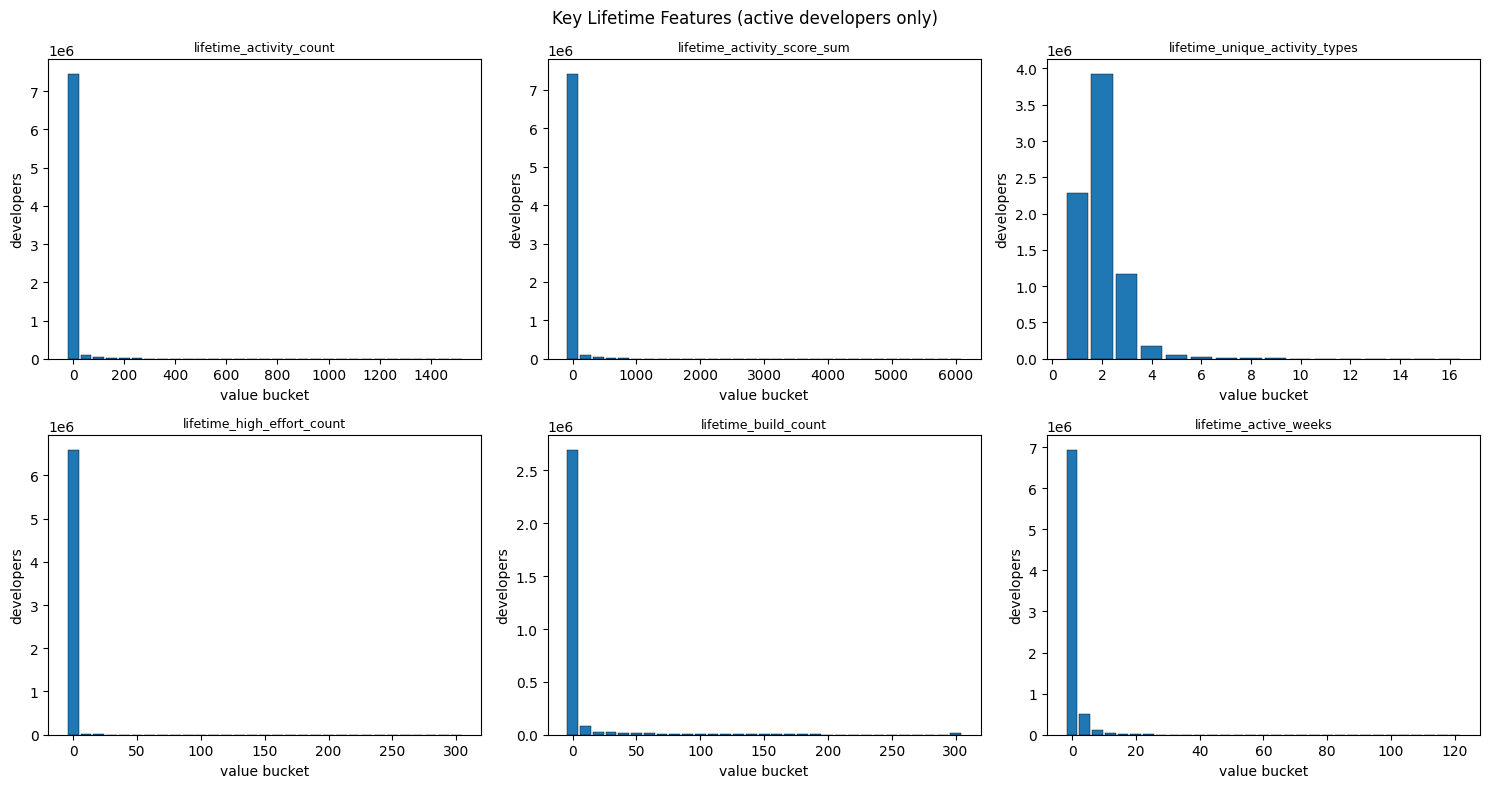

In [18]:
# Histograms for key lifetime counts (active devs only)
lt_cols = [
    ('lifetime_activity_count', 50),
    ('lifetime_activity_score_sum', 200),
    ('lifetime_unique_activity_types', 1),
    ('lifetime_high_effort_count', 10),
    ('lifetime_build_count', 10),
    ('lifetime_active_weeks', 4),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, (col, bucket_size) in enumerate(lt_cols):
    bkt = con.execute(f"""
        SELECT LEAST(FLOOR({col} / {bucket_size}) * {bucket_size}, {bucket_size}*30) AS bucket,
               COUNT(*) AS n
        FROM {TABLE} WHERE {col} > 0
        GROUP BY 1 ORDER BY 1
    """).fetchdf()
    axes[i].bar(bkt['bucket'], bkt['n'], width=bucket_size * 0.85, edgecolor='k', linewidth=0.3)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('value bucket')
    axes[i].set_ylabel('developers')
plt.suptitle('Key Lifetime Features (active developers only)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Weighted / Log / Velocity Features

In [19]:
display(con.execute(f"""
SELECT
    ROUND(MIN(weighted_recent_activity), 4)  AS wra_min,
    ROUND(MAX(weighted_recent_activity), 4)  AS wra_max,
    ROUND(AVG(weighted_recent_activity), 4)  AS wra_avg,
    SUM(CASE WHEN weighted_recent_activity < 0 THEN 1 ELSE 0 END) AS wra_neg,
    ROUND(MIN(log_activity_count_0_30d), 4)  AS log_act_min,
    ROUND(MAX(log_activity_count_0_30d), 4)  AS log_act_max,
    SUM(CASE WHEN log_activity_count_0_30d < 0 THEN 1 ELSE 0 END) AS log_act_neg,
    ROUND(MIN(activity_velocity_0_30_vs_30_90), 4) AS velocity_min,
    ROUND(MAX(activity_velocity_0_30_vs_30_90), 4) AS velocity_max
FROM {TABLE}
""").fetchdf())

,wra_min,wra_max,wra_avg,wra_neg,log_act_min,log_act_max,log_act_neg,velocity_min,velocity_max
0,0.0000,203660.0000,0.3584,0.0000,0.0000,11.8792,0.0000,0.0000,738.0000


## 9. Contact / Metadata Features

In [20]:
for col in ['account_type', 'region', 'industry_segment_vertical',
            'program_application_source', 'wwfo_category']:
    print(f'=== {col} (top 10) ===')
    display(con.execute(f"""
        SELECT {col}, COUNT(*) AS n,
            ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
        FROM {TABLE}
        GROUP BY 1 ORDER BY 2 DESC
        LIMIT 10
    """).fetchdf())

=== account_type (top 10) ===


,account_type,n,pct
0,unknown,6404129,68.2600
1,university,1980017,21.1100
2,enterprise,740459,7.8900
3,startup,215987,2.3000
4,enterprise;university,16654,0.1800
5,startup;university,12856,0.1400
6,enterprise;startup,11388,0.1200
7,NaN,18,0.0000


=== region (top 10) ===


,region,n,pct
0,apac,4284392,45.6700
1,nala,2220135,23.6700
2,emea,2070011,22.0600
3,null,804111,8.5700
4,unknown,2841,0.0300
5,NaN,18,0.0000


=== industry_segment_vertical (top 10) ===


,industry_segment_vertical,n,pct
0,other,4342653,46.2900
1,academia / education,1224186,13.0500
2,aec,594797,6.3400
3,gaming,488951,5.2100
4,cloud services,285473,3.0400
5,media & entertainment,256978,2.7400
6,automotive / transportation,217860,2.3200
7,financial services,217183,2.3200
8,hardware / semiconductor,212841,2.2700
9,healthcare & life sciences,210352,2.2400


=== program_application_source (top 10) ===


,program_application_source,n,pct
0,null,4006295,42.7000
1,devzone,2806574,29.9200
2,dli,1004037,10.7000
3,gtc,448891,4.7800
4,unknown,446092,4.7600
5,api_catalog,391786,4.1800
6,gtc fall 2022,107396,1.1400
7,gtc spring 2022,89807,0.9600
8,nod,46301,0.4900
9,brev,10869,0.1200


=== wwfo_category (top 10) ===


,wwfo_category,n,pct
0,null,7707466,82.1600
1,higher ed/research,1059005,11.2900
2,unknown,397162,4.2300
3,strategic hyperscale,42925,0.4600
4,manufacturing,38125,0.4100
5,automotive,34371,0.3700
6,healthcare,26609,0.2800
7,supercomputing,18224,0.1900
8,crisp (consumer internet service providers),16972,0.1800
9,financial services industry (fsi),13344,0.1400


In [21]:
print('Top 20 countries:')
display(con.execute(f"""
    SELECT country, COUNT(*) AS n,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM {TABLE}
    GROUP BY 1 ORDER BY 2 DESC
    LIMIT 20
""").fetchdf())

Top 20 countries:


,country,n,pct
0,UNITED STATES,1688338,18.0000
1,CHINA,1645122,17.5400
2,INDIA,1111879,11.8500
3,NULL,804111,8.5700
4,"KOREA, REPUBLIC OF",305752,3.2600
5,JAPAN,292502,3.1200
6,GERMANY,238016,2.5400
7,TAIWAN,213672,2.2800
8,UNITED KINGDOM,209229,2.2300
9,CANADA,159076,1.7000


## 10. Outlier Check

In [22]:
print('Top 10 by lifetime_activity_count:')
display(con.execute(f"""
    SELECT developer_id, lifetime_activity_count, lifetime_activity_score_sum,
           lifetime_unique_activity_types, developer_effort_level,
           final_lifecycle_status, country, account_type
    FROM {TABLE}
    ORDER BY lifetime_activity_count DESC NULLS LAST
    LIMIT 10
""").fetchdf())

print('\nTop 10 by developer_effort_score:')
display(con.execute(f"""
    SELECT developer_id, developer_effort_score, developer_effort_level,
           lifetime_activity_count, lifetime_high_effort_count,
           final_lifecycle_status
    FROM {TABLE}
    ORDER BY developer_effort_score DESC NULLS LAST
    LIMIT 10
""").fetchdf())

Top 10 by lifetime_activity_count:


,developer_id,lifetime_activity_count,lifetime_activity_score_sum,lifetime_unique_activity_types,developer_effort_level,final_lifecycle_status,country,account_type
0,5903679,2027375,10015777.0000,2,very high effort,Active_Champion,UNITED STATES,enterprise
1,5886356,789400,3946993.0000,4,very high effort,Active_Build,SINGAPORE,enterprise
2,3931685,187095,935275.0000,1,very high effort,Active_Build,PORTUGAL,startup
3,1303597,151947,450792.0000,3,very high effort,Active_Build,INDIA,enterprise
4,2028858,142980,714580.0000,1,very high effort,Active_Build,UNITED STATES,unknown
5,6309430,121950,235235.0000,5,very high effort,Active_Champion,UNITED STATES,enterprise
6,4634152,107089,180756.0000,1,very high effort,Active_Champion,UNITED STATES,unknown
7,6125204,68992,344961.0000,9,very high effort,Active_Build,THAILAND,unknown
8,4833930,55061,275414.0000,2,very high effort,Dormant_Build,UNITED STATES,enterprise
9,225774,53677,268041.0000,1,high effort,Dormant_Build,UNITED STATES,enterprise



Top 10 by developer_effort_score:


,developer_id,developer_effort_score,developer_effort_level,lifetime_activity_count,lifetime_high_effort_count,final_lifecycle_status
0,5903679,5.3391,very high effort,2027375,2023204.0000,Active_Champion
1,5886356,5.1080,very high effort,789400,789398.0000,Active_Build
2,8388704,5.1020,very high effort,8582,8571.0000,Active_Champion
3,6056403,5.0470,very high effort,17967,17687.0000,Active_Champion
4,6002581,4.9872,very high effort,33768,31771.0000,Active_Champion
5,6112577,4.9820,very high effort,30443,17942.0000,Active_Champion
6,6002252,4.9635,very high effort,18076,17923.0000,Active_Champion
7,4672512,4.9423,very high effort,4242,3671.0000,Active_Champion
8,5671110,4.9257,very high effort,49514,49514.0000,Active_Champion
9,3931685,4.9104,very high effort,187095,187095.0000,Active_Build


In [23]:
# P95 / P99 for key numeric columns
display(con.execute(f"""
SELECT
    ROUND(QUANTILE_CONT(lifetime_activity_count, 0.95), 1)     AS lt_act_p95,
    ROUND(QUANTILE_CONT(lifetime_activity_count, 0.99), 1)     AS lt_act_p99,
    ROUND(QUANTILE_CONT(lifetime_activity_score_sum, 0.95), 1) AS lt_score_p95,
    ROUND(QUANTILE_CONT(lifetime_activity_score_sum, 0.99), 1) AS lt_score_p99,
    ROUND(QUANTILE_CONT(developer_effort_score, 0.95), 4)      AS effort_p95,
    ROUND(QUANTILE_CONT(developer_effort_score, 0.99), 4)      AS effort_p99,
    ROUND(QUANTILE_CONT(activity_count_0_30d, 0.95), 1)        AS act_0_30_p95,
    ROUND(QUANTILE_CONT(activity_count_0_30d, 0.99), 1)        AS act_0_30_p99
FROM {TABLE}
""").fetchdf())

,lt_act_p95,lt_act_p99,lt_score_p95,lt_score_p99,effort_p95,effort_p99,act_0_30_p95,act_0_30_p99
0,15.0000,115.0000,81.0000,352.0000,1.1119,2.0544,0.0000,4.0000


## 11. Cross-Feature Consistency Checks

In [24]:
display(con.execute(f"""
SELECT
    -- Activated but no lifetime activity
    SUM(CASE WHEN is_activated = 0 AND lifetime_activity_count > 0 THEN 1 ELSE 0 END)
        AS unactivated_with_lifetime_activity,

    -- Unactivated lifecycle status but has lifetime activity
    SUM(CASE WHEN final_lifecycle_status = 'Unactivated' AND lifetime_activity_count > 0 THEN 1 ELSE 0 END)
        AS unactivated_status_with_lifetime_activity,

    -- Zero lifetime activity but not marked Unactivated
    SUM(CASE WHEN COALESCE(lifetime_activity_count, 0) = 0 AND final_lifecycle_status <> 'Unactivated' THEN 1 ELSE 0 END)
        AS zero_lifetime_not_unactivated,

    -- recent_build_flag = 1 but build_count_0_30d = 0
    SUM(CASE WHEN recent_build_flag = 1 AND build_count_0_30d = 0 THEN 1 ELSE 0 END)
        AS recent_build_flag_mismatch,

    -- activity_count_0_30d > 0 but has_activity_0_30d = 0
    SUM(CASE WHEN activity_count_0_30d > 0 AND has_activity_0_30d = 0 THEN 1 ELSE 0 END)
        AS activity_flag_mismatch_0_30d,

    -- negative effort score
    SUM(CASE WHEN developer_effort_score < 0 THEN 1 ELSE 0 END)
        AS negative_effort_score,

    -- effort rank out of [0, 4]
    SUM(CASE WHEN developer_effort_rank NOT BETWEEN 0 AND 4 THEN 1 ELSE 0 END)
        AS effort_rank_out_of_range,

    -- persona_confidence out of [0, 1]
    SUM(CASE WHEN persona_confidence < 0 OR persona_confidence > 1 THEN 1 ELSE 0 END)
        AS persona_confidence_out_of_range,

    -- persona_entropy out of [0, 1]
    SUM(CASE WHEN persona_entropy < -0.000001 OR persona_entropy > 1.000001 THEN 1 ELSE 0 END)
        AS persona_entropy_out_of_range,

    -- missing contact flag not binary
    SUM(CASE WHEN missing_contact_metadata_flag NOT IN (0, 1) THEN 1 ELSE 0 END)
        AS contact_flag_not_binary

FROM {TABLE}
""").fetchdf().T.rename(columns={0: 'violations'}))

,violations
unactivated_with_lifetime_activity,0.0000
unactivated_status_with_lifetime_activity,0.0000
zero_lifetime_not_unactivated,0.0000
recent_build_flag_mismatch,0.0000
activity_flag_mismatch_0_30d,0.0000
negative_effort_score,0.0000
effort_rank_out_of_range,0.0000
persona_confidence_out_of_range,0.0000
persona_entropy_out_of_range,0.0000
contact_flag_not_binary,0.0000


## 12. Summary Statistics by Lifecycle Status & Effort Level

In [25]:
print('=== Key metrics by final_lifecycle_status ===')
display(con.execute(f"""
SELECT
    final_lifecycle_status,
    COUNT(*) AS developers,
    ROUND(AVG(lifetime_activity_count), 2)    AS avg_lt_activity,
    ROUND(MEDIAN(lifetime_activity_count), 2) AS med_lt_activity,
    ROUND(AVG(lifetime_activity_score_sum), 2) AS avg_lt_score,
    ROUND(AVG(developer_effort_score), 4)     AS avg_effort_score,
    ROUND(AVG(activity_count_0_30d), 2)       AS avg_act_0_30d,
    ROUND(AVG(lifetime_unique_activity_types), 2) AS avg_lt_types
FROM {TABLE}
GROUP BY 1
ORDER BY developers DESC
""").fetchdf())

=== Key metrics by final_lifecycle_status ===


,final_lifecycle_status,developers,avg_lt_activity,med_lt_activity,avg_lt_score,avg_effort_score,avg_act_0_30d,avg_lt_types
0,Tourist,4976445,2.0100,2.0000,8.0500,0.4204,0.0800,1.6500
1,Unactivated,1721230,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,Dormant_Build,1015390,19.8000,6.0000,59.7700,0.5656,0.0000,2.5400
3,Dormant_Learn,360345,5.4800,3.0000,54.6200,0.5342,0.0000,2.3800
4,Dormant_Evaluate,233676,6.0100,4.0000,20.8200,0.4904,0.0000,2.7400
5,AtRisk_Build,212335,25.3400,6.0000,81.1300,0.5786,0.0000,2.6900
6,Active_Build,198074,51.6700,9.0000,172.3900,1.8213,2.6700,2.8000
7,Active_Discover,141923,35.6200,8.0000,3.2000,1.0983,13.7000,1.9300
8,AtRisk_Learn,115334,6.8900,3.0000,64.1400,0.5509,0.0000,2.5900
9,FreeEmail,109622,5.5700,4.0000,16.7800,0.5014,0.0900,1.7100


In [26]:
print('=== Effort level x lifecycle status cross-tab ===')
display(con.execute(f"""
SELECT
    developer_effort_level,
    developer_effort_rank,
    final_lifecycle_status,
    COUNT(*) AS developers
FROM {TABLE}
GROUP BY 1, 2, 3
ORDER BY developer_effort_rank DESC, developers DESC
LIMIT 40
""").fetchdf())

=== Effort level x lifecycle status cross-tab ===


,developer_effort_level,developer_effort_rank,final_lifecycle_status,developers
0,very high effort,4,Tourist,346425
1,very high effort,4,Active_Build,166250
2,very high effort,4,Active_Discover,103927
3,very high effort,4,Active_Learn,70504
4,very high effort,4,Active_Evaluate,20604
5,very high effort,4,Dormant_Build,19241
6,very high effort,4,Active_Champion,15660
7,very high effort,4,Dormant_Champion,8300
8,very high effort,4,AtRisk_Build,7180
9,very high effort,4,FreeEmail,4065


In [ ]:
con.close()